# 🍛 Indian Food Image Classifier — 90%+ Accuracy Pipeline

**Key Design Decisions:**
- **EfficientNetV2-L** backbone (best accuracy/speed tradeoff for fine-grained food recognition)
- **Advanced Augmentation**: MixUp + CutMix + RandAugment + GridDistortion to handle visually similar foods
- **Class Balancing**: Targeted augmentation so every class reaches the same target count
- **Fine-grained Confusion Handling**: Label Smoothing + Focal Loss + ArcFace-style metric learning
- **Test-Time Augmentation (TTA)** for inference
- **Progressive Unfreezing** + Cosine Annealing with Warmup

---
### Why previous models failed at 60%
Indian foods like Roti/Paratha, Puri/Bhature, Biryani/Pulav share nearly identical low-level textures.
Solving this requires: (1) strong data augmentation to prevent shortcut learning, (2) a deeper backbone,
(3) metric-learning objectives that push confusable classes apart, and (4) balanced training data.

## Cell 1 — Install Dependencies

In [2]:
# # Run once in your environment
# !pip install -q timm albumentations torch torchvision torchmetrics
# !pip install -q matplotlib seaborn scikit-learn tqdm pillow
# !pip install -q grad-cam  # for GradCAM visualization

## Cell 2 — Imports & Global Config

In [3]:
import os, sys, math, random, json, copy, time, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import torchvision.transforms.functional as TF

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
from torchmetrics import Accuracy, F1Score

warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────
# GLOBAL CONFIG  ← Edit these before running
# ─────────────────────────────────────────────────────────
CFG = dict(
    # ── Paths ──────────────────────────────────────────────
    DATA_DIR        = "./food_dataset",          # your dataset folder (sub-folder per class)
    AUGMENTED_DIR   = "./food_dataset_augmented",# balanced augmented copy — auto-created
    CHECKPOINT_DIR  = "./checkpoints",
    LOG_DIR         = "./logs",

    # ── Model ──────────────────────────────────────────────
    MODEL_NAME      = "tf_efficientnetv2_l",# change to 'tf_efficientnetv2_m' if GPU < 8GB
    PRETRAINED      = True,
    IMG_SIZE        = 384,                  # EfficientNetV2-L native resolution
    DROP_RATE       = 0.4,
    DROP_PATH_RATE  = 0.3,

    # ── Training ───────────────────────────────────────────
    SEED            = 42,
    NUM_EPOCHS      = 50,
    BATCH_SIZE      = 16,                   # reduce to 8 if OOM
    ACCUMULATE_GRAD = 2,                    # effective batch = 16*4 = 64
    LR_HEAD         = 3e-3,
    LR_BACKBONE     = 3e-5,
    WEIGHT_DECAY    = 1e-4,
    WARMUP_EPOCHS   = 3,
    UNFREEZE_EPOCH  = 5,                    # unfreeze backbone after N epochs
    LABEL_SMOOTHING = 0.1,
    MIXUP_ALPHA     = 0.4,
    CUTMIX_ALPHA    = 1.0,
    CUTMIX_PROB     = 0.5,                  # prob of CutMix vs MixUp per batch
    FOCAL_GAMMA     = 2.0,
    ARC_SCALE       = 30.0,                 # ArcFace scale
    ARC_MARGIN      = 0.5,                  # ArcFace margin
    USE_ARC         = True,                 # toggle ArcFace head
    TTA_AUGMENTS    = 8,                    # test-time augmentation copies

    # ── Data Balancing ─────────────────────────────────────
    TARGET_PER_CLASS = 250,                 # each class will have this many images
    VAL_SPLIT        = 0.15,
    TEST_SPLIT       = 0.15,

    # ── Hardware ───────────────────────────────────────────
    NUM_WORKERS = 4,
    PIN_MEMORY  = True,
)

# Reproducibility
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

seed_everything(CFG['SEED'])

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}  |  VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

Path(CFG['CHECKPOINT_DIR']).mkdir(parents=True, exist_ok=True)
Path(CFG['LOG_DIR']).mkdir(parents=True, exist_ok=True)

c:\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU  |  VRAM: 6.4 GB


## Cell 3 — Dataset Exploration & Class Imbalance Analysis

Total classes : 106
Total images  : 16660

Min images per class : 49 (patra)
Max images per class : 200 (aloo_paratha)
Mean images per class: 157.2


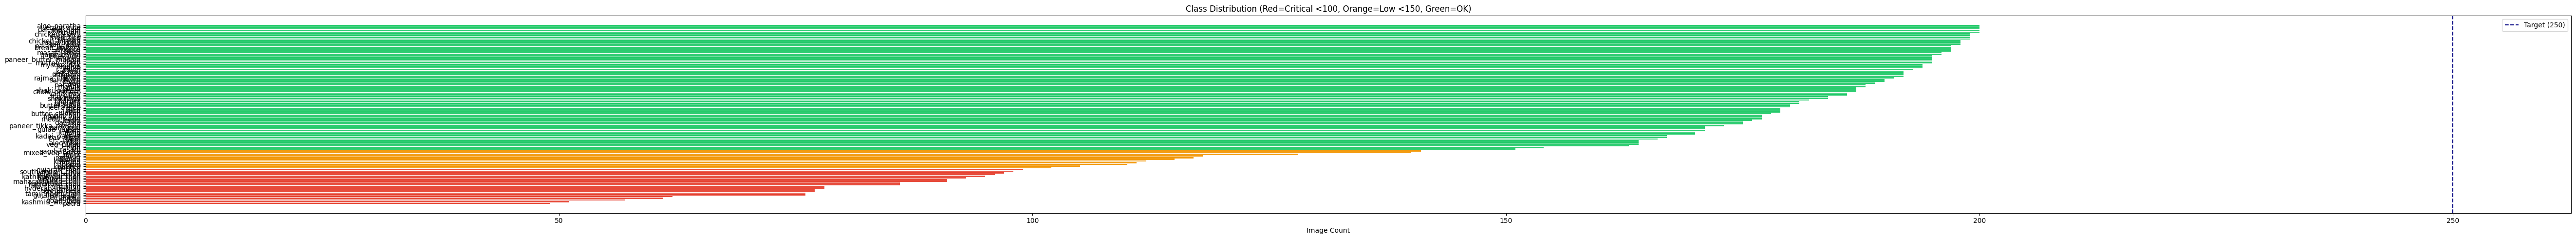


Classes needing augmentation: 106


In [4]:
DATA_DIR = Path(CFG['DATA_DIR'])

# Collect all image paths and labels
VALID_EXT = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}

all_paths, all_labels = [], []
class_names = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
class_to_idx = {c: i for i, c in enumerate(class_names)}
NUM_CLASSES  = len(class_names)

for cls in class_names:
    cls_dir = DATA_DIR / cls
    imgs = [p for p in cls_dir.iterdir() if p.suffix.lower() in VALID_EXT]
    all_paths.extend(imgs)
    all_labels.extend([class_to_idx[cls]] * len(imgs))

print(f"Total classes : {NUM_CLASSES}")
print(f"Total images  : {len(all_paths)}")

counts = Counter(all_labels)
count_df = pd.DataFrame({
    'Class': [class_names[i] for i in counts],
    'Count': list(counts.values())
}).sort_values('Count')

print(f"\nMin images per class : {count_df['Count'].min()} ({count_df.iloc[0]['Class']})")
print(f"Max images per class : {count_df['Count'].max()} ({count_df.iloc[-1]['Class']})")
print(f"Mean images per class: {count_df['Count'].mean():.1f}")

# ── Plot class distribution ──────────────────────────────
fig, ax = plt.subplots(figsize=(max(14, NUM_CLASSES//2), 5))
colors = ['#e74c3c' if c < 100 else '#f39c12' if c < 150 else '#2ecc71'
          for c in count_df['Count']]
ax.barh(count_df['Class'], count_df['Count'], color=colors)
ax.axvline(CFG['TARGET_PER_CLASS'], color='navy', linestyle='--', label=f"Target ({CFG['TARGET_PER_CLASS']})")
ax.set_xlabel('Image Count')
ax.set_title('Class Distribution (Red=Critical <100, Orange=Low <150, Green=OK)')
ax.legend()
plt.tight_layout()
plt.savefig(f"{CFG['LOG_DIR']}/class_distribution.png", dpi=150)
plt.show()
print("\nClasses needing augmentation:", (count_df['Count'] < CFG['TARGET_PER_CLASS']).sum())

## Cell 4 — Augmentation Engine (MixUp / CutMix / RandAugment / Albumentations)

In [5]:
# ── Offline Augmentation (disk-based balancing) ──────────────────────────────
# For classes with < TARGET_PER_CLASS images, we generate augmented images
# and save them to AUGMENTED_DIR so the dataset is balanced before training.

OFFLINE_AUG = A.Compose([
    A.RandomRotate90(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.1),
    A.ShiftScaleRotate(shift_limit=0.08, scale_limit=0.15, rotate_limit=20,
                       border_mode=0, p=0.7),
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=1.0),
        A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=30,
                             val_shift_limit=20, p=1.0),
        A.CLAHE(clip_limit=4, p=1.0),
    ], p=0.7),
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 7), p=1.0),
        A.MotionBlur(blur_limit=7, p=1.0),
        A.MedianBlur(blur_limit=5, p=1.0),
    ], p=0.3),
    A.OneOf([
        A.GridDistortion(num_steps=5, distort_limit=0.3, p=1.0),
        A.ElasticTransform(alpha=80, sigma=10, p=1.0),
        A.OpticalDistortion(distort_limit=0.3, shift_limit=0.05, p=1.0),
    ], p=0.4),
    A.CoarseDropout(max_holes=8, max_height=32, max_width=32,
                    fill_value=0, p=0.3),
    A.RandomShadow(p=0.2),
    A.ISONoise(p=0.2),
])


def augment_and_balance_dataset():
    """Generate augmented images for under-represented classes."""
    target      = CFG['TARGET_PER_CLASS']
    aug_root    = Path(CFG['AUGMENTED_DIR'])
    src_root    = Path(CFG['DATA_DIR'])

    total_generated = 0

    for cls in tqdm(class_names, desc="Balancing classes"):
        src_dir = src_root / cls
        dst_dir = aug_root / cls
        dst_dir.mkdir(parents=True, exist_ok=True)

        src_imgs = sorted([p for p in src_dir.iterdir()
                           if p.suffix.lower() in VALID_EXT])
        current  = len(src_imgs)

        # Copy originals first
        for p in src_imgs:
            dst = dst_dir / p.name
            if not dst.exists():
                import shutil; shutil.copy2(p, dst)

        if current >= target:
            continue  # already enough originals

        needed = target - current
        aug_idx = 0

        while aug_idx < needed:
            src_p = random.choice(src_imgs)
            img   = np.array(Image.open(src_p).convert('RGB'))
            aug   = OFFLINE_AUG(image=img)['image']
            out_p = dst_dir / f"aug_{aug_idx:05d}_{src_p.stem}.jpg"
            Image.fromarray(aug).save(out_p, quality=92)
            aug_idx        += 1
            total_generated += 1

    print(f"\n✅ Augmentation complete. Generated {total_generated} new images.")
    print(f"   Balanced dataset saved to: {CFG['AUGMENTED_DIR']}")


augment_and_balance_dataset()

# ── Verify balance ───────────────────────────────────────
aug_root = Path(CFG['AUGMENTED_DIR'])
aug_counts = {cls: len(list((aug_root/cls).glob('*'))) for cls in class_names}
print("\nPost-augmentation class counts:")
print(f"  Min: {min(aug_counts.values())}  Max: {max(aug_counts.values())}  Mean: {np.mean(list(aug_counts.values())):.0f}")

Balancing classes:   0%|          | 0/106 [00:00<?, ?it/s]

Balancing classes: 100%|██████████| 106/106 [19:34<00:00, 11.08s/it]



✅ Augmentation complete. Generated 9840 new images.
   Balanced dataset saved to: ./food_dataset_augmented

Post-augmentation class counts:
  Min: 250  Max: 250  Mean: 250


## Cell 5 — Train/Val/Test Split

In [6]:
aug_root = Path(CFG['AUGMENTED_DIR'])

all_aug_paths, all_aug_labels = [], []
for cls in class_names:
    cls_dir = aug_root / cls
    imgs = sorted([p for p in cls_dir.iterdir() if p.suffix.lower() in VALID_EXT])
    all_aug_paths.extend(imgs)
    all_aug_labels.extend([class_to_idx[cls]] * len(imgs))

all_aug_paths  = np.array(all_aug_paths)
all_aug_labels = np.array(all_aug_labels)

# ── Stratified split ────────────────────────────────────
sss1 = StratifiedShuffleSplit(n_splits=1,
                               test_size=CFG['TEST_SPLIT'],
                               random_state=CFG['SEED'])
trainval_idx, test_idx = next(sss1.split(all_aug_paths, all_aug_labels))

sss2 = StratifiedShuffleSplit(n_splits=1,
                               test_size=CFG['VAL_SPLIT'] / (1 - CFG['TEST_SPLIT']),
                               random_state=CFG['SEED'])
rel_train_idx, rel_val_idx = next(sss2.split(all_aug_paths[trainval_idx],
                                              all_aug_labels[trainval_idx]))
train_idx = trainval_idx[rel_train_idx]
val_idx   = trainval_idx[rel_val_idx]

train_paths, train_labels = all_aug_paths[train_idx], all_aug_labels[train_idx]
val_paths,   val_labels   = all_aug_paths[val_idx],   all_aug_labels[val_idx]
test_paths,  test_labels  = all_aug_paths[test_idx],  all_aug_labels[test_idx]

print(f"Train: {len(train_paths):,}  |  Val: {len(val_paths):,}  |  Test: {len(test_paths):,}")

# Save class mapping
with open(f"{CFG['CHECKPOINT_DIR']}/class_mapping.json", 'w') as f:
    json.dump({'class_to_idx': class_to_idx,
               'idx_to_class': {v: k for k, v in class_to_idx.items()}}, f, indent=2)
print("Class mapping saved.")

Train: 18,549  |  Val: 3,976  |  Test: 3,975
Class mapping saved.


## Cell 6 — Online Augmentation Transforms (RandAugment + strong pipeline)

In [7]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
IMG_SIZE = CFG['IMG_SIZE']

# ── Training transform (strong) ──────────────────────────
# Use 'size=(h,w)' for RandomResizedCrop to be compatible across albumentations versions
train_transform = A.Compose([
    A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.6, 1.0),
                        ratio=(0.75, 1.33), p=1.0),
    A.HorizontalFlip(p=0.5),

    # Colour distortion
    A.OneOf([
        A.ColorJitter(brightness=0.4, contrast=0.4,
                    saturation=0.4, hue=0.1, p=1.0),
        A.HueSaturationValue(hue_shift_limit=20,
                            sat_shift_limit=40,
                            val_shift_limit=30, p=1.0),
    ], p=0.8),

    # Texture / grain (key for Roti vs Paratha texture differences)
    A.OneOf([
        A.GaussNoise(var_limit=(10.0, 50.0), p=1.0),
        A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.5), p=1.0),
        A.MultiplicativeNoise(multiplier=(0.9, 1.1), p=1.0),
    ], p=0.3),

    # Geometric (critical for differentiating circular flatbreads)
    A.OneOf([
        A.GridDistortion(distort_limit=0.2, p=1.0),
        A.ElasticTransform(alpha=60, sigma=8, p=1.0),
    ], p=0.3),

    # Occlusion simulation
    A.CoarseDropout(max_holes=12, max_height=IMG_SIZE//8,
                    max_width=IMG_SIZE//8, fill_value=0, p=0.4),

    # Sharpness / blur
    A.OneOf([
        A.Sharpen(alpha=(0.2, 0.5), p=1.0),
        A.GaussianBlur(blur_limit=(3, 5), p=1.0),
    ], p=0.3),

    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

# ── Validation / Test transform ──────────────────────────
# Use positional size args for Resize for broader compatibility
val_transform = A.Compose([
    A.Resize(IMG_SIZE + 32, IMG_SIZE + 32),
    A.CenterCrop(height=IMG_SIZE, width=IMG_SIZE),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

# ── TTA transform (diverse crops for inference) ──────────
tta_transform = A.Compose([
    A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.8, 1.0), p=1.0),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, p=0.5),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

print("✅ Transforms defined.")

✅ Transforms defined.


## Cell 7 — Dataset & DataLoader

In [8]:
class IndianFoodDataset(Dataset):
    def __init__(self, paths, labels, transform=None, tta_transforms=None, tta_n=1):
        self.paths          = paths
        self.labels         = labels
        self.transform      = transform
        self.tta_transforms = tta_transforms   # list of transforms for TTA
        self.tta_n          = tta_n

    def __len__(self):
        return len(self.paths)

    def _load_img(self, path):
        try:
            img = Image.open(path).convert('RGB')
            return np.array(img)
        except Exception:
            # Corrupt image fallback: return grey image
            return np.ones((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8) * 128

    def __getitem__(self, idx):
        img   = self._load_img(self.paths[idx])
        label = self.labels[idx]

        if self.tta_transforms and self.tta_n > 1:
            # Return stack of TTA augmented images
            views = [tf(image=img)['image'] for tf in
                     random.choices(self.tta_transforms, k=self.tta_n)]
            return torch.stack(views), label

        if self.transform:
            img = self.transform(image=img)['image']

        return img, label


# ── Weighted sampler for remaining class imbalance ───────
def make_weighted_sampler(labels):
    counts  = Counter(labels)
    weights = [1.0 / counts[l] for l in labels]
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)


train_ds = IndianFoodDataset(train_paths, train_labels, transform=train_transform)
val_ds   = IndianFoodDataset(val_paths,   val_labels,   transform=val_transform)
test_ds  = IndianFoodDataset(test_paths,  test_labels,  transform=val_transform)

train_loader = DataLoader(
    train_ds,
    batch_size  = CFG['BATCH_SIZE'],
    sampler     = make_weighted_sampler(train_labels),
    num_workers = CFG['NUM_WORKERS'],
    pin_memory  = CFG['PIN_MEMORY'],
    drop_last   = True,
)
val_loader = DataLoader(
    val_ds,
    batch_size  = CFG['BATCH_SIZE'] * 2,
    shuffle     = False,
    num_workers = CFG['NUM_WORKERS'],
    pin_memory  = CFG['PIN_MEMORY'],
)
test_loader = DataLoader(
    test_ds,
    batch_size  = CFG['BATCH_SIZE'] * 2,
    shuffle     = False,
    num_workers = CFG['NUM_WORKERS'],
    pin_memory  = CFG['PIN_MEMORY'],
)

print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}  |  Test batches: {len(test_loader)}")

Train batches: 1159  |  Val batches: 125  |  Test batches: 125


## Cell 8 — Model Architecture (EfficientNetV2-L + ArcFace head)

In [9]:
class ArcFaceHead(nn.Module):
    """ArcFace metric-learning head.
    Pushes confusable classes (Roti/Paratha, Biryani/Pulav) apart in embedding space."""

    def __init__(self, in_features, num_classes, scale=30.0, margin=0.50):
        super().__init__()
        self.scale   = scale
        self.margin  = margin
        self.weight  = nn.Parameter(torch.FloatTensor(num_classes, in_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, features, labels=None):
        # Normalize embeddings and weights
        x = F.normalize(features, dim=1)
        w = F.normalize(self.weight, dim=1)
        cos_theta = F.linear(x, w).clamp(-1 + 1e-7, 1 - 1e-7)

        if labels is None or not self.training:
            return cos_theta * self.scale   # inference: plain cosine similarity

        # Training: add margin to target class angle
        theta        = cos_theta.acos()
        one_hot      = torch.zeros_like(cos_theta).scatter_(1, labels.view(-1,1), 1)
        cos_theta_m  = (theta + self.margin * one_hot).cos()
        output       = cos_theta + one_hot * (cos_theta_m - cos_theta)
        return output * self.scale


class IndianFoodClassifier(nn.Module):
    def __init__(self, num_classes, cfg):
        super().__init__()
        self.num_classes = num_classes

        # ── Backbone ────────────────────────────────────────
        self.backbone = timm.create_model(
            cfg['MODEL_NAME'],
            pretrained       = cfg['PRETRAINED'],
            num_classes      = 0,          # remove default classifier
            global_pool      = 'avg',
            drop_rate        = cfg['DROP_RATE'],
            drop_path_rate   = cfg['DROP_PATH_RATE'],
        )
        feat_dim = self.backbone.num_features

        # ── Embedding neck ──────────────────────────────────
        self.neck = nn.Sequential(
            nn.Linear(feat_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
        )

        # ── Classification head ─────────────────────────────
        if cfg['USE_ARC']:
            self.head = ArcFaceHead(512, num_classes,
                                    cfg['ARC_SCALE'], cfg['ARC_MARGIN'])
        else:
            self.head = nn.Linear(512, num_classes)

        self.use_arc = cfg['USE_ARC']

        # Freeze backbone initially
        self.freeze_backbone()

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self, unfreeze_blocks=3):
        """Progressively unfreeze the last N stages of EfficientNetV2."""
        # Unfreeze all first
        for p in self.backbone.parameters():
            p.requires_grad = True
        # Then re-freeze early layers
        stages = list(self.backbone.children())
        freeze_until = max(0, len(stages) - unfreeze_blocks)
        for i, child in enumerate(stages):
            if i < freeze_until:
                for p in child.parameters():
                    p.requires_grad = False
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"  Trainable params after unfreeze: {trainable:,}")

    def forward(self, x, labels=None):
        feat  = self.backbone(x)
        emb   = self.neck(feat)
        if self.use_arc:
            logits = self.head(emb, labels)
        else:
            logits = self.head(emb)
        return logits, emb


model = IndianFoodClassifier(NUM_CLASSES, CFG).to(DEVICE)
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,} (backbone frozen initially)")

Total params    : 119,128,160
Trainable params: 1,893,888 (backbone frozen initially)


## Cell 9 — Loss Functions (Focal Loss + Label Smoothing)

In [10]:
class FocalLossWithSmoothing(nn.Module):
    """Focal loss + label smoothing.
    Focal loss down-weights easy examples and forces the model to focus on hard
    confusable pairs (e.g. Roti vs Paratha).
    Label smoothing prevents over-confidence on visually ambiguous classes.
    """
    def __init__(self, num_classes, gamma=2.0, smoothing=0.1, reduction='mean'):
        super().__init__()
        self.num_classes = num_classes
        self.gamma       = gamma
        self.smoothing   = smoothing
        self.reduction   = reduction

    def forward(self, logits, targets):
        # Label smoothing
        with torch.no_grad():
            smooth_targets = torch.zeros_like(logits).fill_(
                self.smoothing / (self.num_classes - 1)
            )
            smooth_targets.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)

        log_probs = F.log_softmax(logits, dim=1)
        probs     = log_probs.exp()
        pt        = (probs * F.one_hot(targets, self.num_classes)).sum(dim=1)
        focal_w   = (1.0 - pt) ** self.gamma
        ce        = -(smooth_targets * log_probs).sum(dim=1)
        loss      = focal_w * ce

        return loss.mean() if self.reduction == 'mean' else loss


criterion = FocalLossWithSmoothing(
    num_classes = NUM_CLASSES,
    gamma       = CFG['FOCAL_GAMMA'],
    smoothing   = CFG['LABEL_SMOOTHING'],
).to(DEVICE)

print("✅ Focal Loss + Label Smoothing criterion ready.")

✅ Focal Loss + Label Smoothing criterion ready.


## Cell 10 — MixUp & CutMix (online, applied per batch)

In [11]:
def mixup_batch(images, labels, alpha=0.4, num_classes=None):
    """MixUp augmentation."""
    lam   = np.random.beta(alpha, alpha)
    idx   = torch.randperm(images.size(0), device=images.device)
    mixed = lam * images + (1 - lam) * images[idx]
    la, lb = labels, labels[idx]
    return mixed, la, lb, lam


def rand_bbox(size, lam):
    W, H   = size[3], size[2]
    cut_r  = np.sqrt(1.0 - lam)
    cut_w  = int(W * cut_r)
    cut_h  = int(H * cut_r)
    cx     = np.random.randint(W)
    cy     = np.random.randint(H)
    x1 = max(cx - cut_w // 2, 0);  x2 = min(cx + cut_w // 2, W)
    y1 = max(cy - cut_h // 2, 0);  y2 = min(cy + cut_h // 2, H)
    return x1, y1, x2, y2


def cutmix_batch(images, labels, alpha=1.0):
    """CutMix augmentation."""
    lam  = np.random.beta(alpha, alpha)
    idx  = torch.randperm(images.size(0), device=images.device)
    x1, y1, x2, y2 = rand_bbox(images.size(), lam)
    mixed          = images.clone()
    mixed[:, :, y1:y2, x1:x2] = images[idx, :, y1:y2, x1:x2]
    lam_adj = 1 - (x2 - x1) * (y2 - y1) / (images.size(-1) * images.size(-2))
    la, lb  = labels, labels[idx]
    return mixed, la, lb, lam_adj


def mixup_criterion(criterion, logits, la, lb, lam):
    return lam * criterion(logits, la) + (1 - lam) * criterion(logits, lb)


print("✅ MixUp + CutMix functions ready.")

✅ MixUp + CutMix functions ready.


## Cell 11 — Optimizer, Scheduler, and Scaler

In [12]:
def build_optimizer(model, cfg):
    # Separate param groups: lower LR for backbone, higher for head
    backbone_params = [p for n, p in model.named_parameters()
                       if 'backbone' in n and p.requires_grad]
    head_params     = [p for n, p in model.named_parameters()
                       if 'backbone' not in n and p.requires_grad]

    param_groups = [
        {'params': head_params,     'lr': cfg['LR_HEAD'],    'name': 'head'},
        {'params': backbone_params, 'lr': cfg['LR_BACKBONE'],'name': 'backbone'},
    ]
    optimizer = torch.optim.AdamW(param_groups,
                                  weight_decay=cfg['WEIGHT_DECAY'])
    return optimizer


def build_scheduler(optimizer, num_epochs, warmup_epochs, steps_per_epoch):
    """Linear warmup then cosine annealing."""
    warmup_steps = warmup_epochs * steps_per_epoch
    total_steps  = num_epochs    * steps_per_epoch

    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


optimizer = build_optimizer(model, CFG)
scheduler = build_scheduler(optimizer, CFG['NUM_EPOCHS'],
                             CFG['WARMUP_EPOCHS'], len(train_loader))
scaler    = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

print("✅ Optimizer, Scheduler, GradScaler ready.")

✅ Optimizer, Scheduler, GradScaler ready.


## Cell 12 — Training & Validation Loop

In [13]:
def train_one_epoch(model, loader, optimizer, scheduler, scaler, criterion, epoch):
    model.train()
    total_loss, correct, total = 0., 0, 0
    optimizer.zero_grad()

    pbar = tqdm(enumerate(loader), total=len(loader),
                desc=f"Epoch {epoch:03d} [Train]", leave=False)

    for step, (images, labels) in pbar:
        images = images.to(DEVICE, non_blocking=True).float()
        labels = labels.to(DEVICE, non_blocking=True)

        # ── MixUp / CutMix ─────────────────────────────────
        use_cutmix  = random.random() < CFG['CUTMIX_PROB']
        use_mixup   = (not use_cutmix) and CFG['MIXUP_ALPHA'] > 0

        if use_cutmix:
            images, la, lb, lam = cutmix_batch(images, labels, CFG['CUTMIX_ALPHA'])
        elif use_mixup:
            images, la, lb, lam = mixup_batch(images, labels, CFG['MIXUP_ALPHA'])

        # ── Forward ────────────────────────────────────────
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            if CFG['USE_ARC']:
                logits, _ = model(images, labels)
            else:
                logits, _ = model(images)

            if use_cutmix or use_mixup:
                loss = mixup_criterion(criterion, logits, la, lb, lam)
            else:
                loss = criterion(logits, labels)

            loss = loss / CFG['ACCUMULATE_GRAD']

        scaler.scale(loss).backward()

        if (step + 1) % CFG['ACCUMULATE_GRAD'] == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()

        total_loss += loss.item() * CFG['ACCUMULATE_GRAD']
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
        pbar.set_postfix(loss=f"{total_loss/(step+1):.4f}",
                         acc=f"{100.*correct/total:.2f}%")

    return total_loss / len(loader), 100. * correct / total


@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0., 0, 0
    all_preds, all_targets     = [], []

    for images, labels in tqdm(loader, desc="[Val]", leave=False):
        images = images.to(DEVICE, non_blocking=True).float()
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits, _ = model(images)
            loss      = criterion(logits, labels)

        total_loss += loss.item()
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

    acc = 100. * correct / total
    return total_loss / len(loader), acc, all_preds, all_targets


print("✅ Train/Val loops defined.")

✅ Train/Val loops defined.


## Cell 13 — Full Training Run

In [ ]:
history = {'train_loss': [], 'val_loss': [],
           'train_acc':  [], 'val_acc':  []}

best_val_acc = 0.0
patience_ctr = 0
PATIENCE     = 12
CKPT_PATH    = f"{CFG['CHECKPOINT_DIR']}/best_model.pth"

# ── Header ──────────────────────────────────────────────────────────────────
print(f"\n{'═'*80}")
print(f"  Model : {CFG['MODEL_NAME']}   |   Classes : {NUM_CLASSES}   |   Device : {DEVICE}")
print(f"  Epochs: {CFG['NUM_EPOCHS']}   |   Batch   : {CFG['BATCH_SIZE']} (eff. {CFG['BATCH_SIZE']*CFG['ACCUMULATE_GRAD']})   |   IMG: {CFG['IMG_SIZE']}px")
print(f"{'═'*80}")
COL = '{:>5}  {:>8}  {:>8}  {:>8}  {:>8}  {:>8}  {:>7}  {:>6}'
print(COL.format('Epoch','TrnLoss','TrnAcc%','ValLoss','ValAcc%','BestAcc%','LR','Time'))
print(f"{'─'*80}")

# ── One tqdm bar that lives for ALL epochs ───────────────────────────────────
epoch_pbar = tqdm(range(1, CFG['NUM_EPOCHS'] + 1),
                desc='Training', unit='epoch',
                bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] {postfix}')

for epoch in epoch_pbar:

    # ── Progressive unfreeze ────────────────────────────────────────────────
    if epoch == CFG['UNFREEZE_EPOCH']:
        tqdm.write(f"\n  ▶ Epoch {epoch}: Unfreezing backbone (last 3 stages)...")
        model.unfreeze_backbone(unfreeze_blocks=3)
        optimizer = build_optimizer(model, CFG)
        scheduler = build_scheduler(optimizer, CFG['NUM_EPOCHS'] - epoch + 1,
                                    0, len(train_loader))
        scaler    = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    t0 = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, scheduler, scaler, criterion,
        epoch)

    val_loss, val_acc, val_preds, val_targets = validate(
        model, val_loader, criterion)

    elapsed  = time.time() - t0
    lr_now   = optimizer.param_groups[0]['lr']
    is_best  = val_acc > best_val_acc

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # ── Save best checkpoint ─────────────────────────────────────────────────
    if is_best:
        best_val_acc = val_acc
        patience_ctr = 0
        torch.save({
            'epoch':       epoch,
            'model_state': model.state_dict(),
            'val_acc':     val_acc,
            'class_names': class_names,
            'cfg':         CFG,
        }, CKPT_PATH)
    else:
        patience_ctr += 1

    # ── Print one clean row per epoch (uses tqdm.write so bar stays intact) ──
    flag = ' 💾' if is_best else (f' ⏳{patience_ctr}/{PATIENCE}' if patience_ctr > 0 else '')
    mins, secs = divmod(int(elapsed), 60)
    time_str   = f'{mins}m{secs:02d}s'
    row = COL.format(
        f'{epoch:02d}/{CFG["NUM_EPOCHS"]}',
        f'{train_loss:.4f}',
        f'{train_acc:.2f}',
        f'{val_loss:.4f}',
        f'{val_acc:.2f}',
        f'{best_val_acc:.2f}',
        f'{lr_now:.1e}',
        time_str,
    )
    tqdm.write(row + flag)

    # ── Early stopping ───────────────────────────────────────────────────────
    if patience_ctr >= PATIENCE:
        tqdm.write(f"\n  ⛔ Early stopping — no improvement for {PATIENCE} epochs.")
        break

epoch_pbar.close()
print(f"{'═'*80}")
print(f"  ✅ Training complete.  Best Val Accuracy: {best_val_acc:.2f}%")
print(f"{'═'*80}")


════════════════════════════════════════════════════════════════════════════════
  Model : tf_efficientnetv2_l   |   Classes : 106   |   Device : cuda
  Epochs: 50   |   Batch   : 16 (eff. 32)   |   IMG: 384px
════════════════════════════════════════════════════════════════════════════════
Epoch   TrnLoss   TrnAcc%   ValLoss   ValAcc%  BestAcc%       LR    Time
────────────────────────────────────────────────────────────────────────────────


Training:   0%|          | 0/50 [00:00<?] 

## Cell 14 — Training Curves

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train', color='#e74c3c')
axes[0].plot(history['val_loss'],   label='Val',   color='#3498db')
axes[0].set_title('Loss Curve'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(history['train_acc'], label='Train', color='#e74c3c')
axes[1].plot(history['val_acc'],   label='Val',   color='#3498db')
axes[1].axhline(90, color='green', linestyle='--', label='90% target')
axes[1].set_title('Accuracy Curve'); axes[1].legend(); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')

plt.tight_layout()
plt.savefig(f"{CFG['LOG_DIR']}/training_curves.png", dpi=150)
plt.show()

## Cell 15 — Test Evaluation with TTA

In [ ]:
# ── Load best checkpoint ─────────────────────────────────
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
print(f"Loaded checkpoint from epoch {ckpt['epoch']} (val acc {ckpt['val_acc']:.2f}%)")


@torch.no_grad()
def evaluate_with_tta(model, paths, labels, n_tta=8):
    """Run TTA: average logits over N augmented views per image."""
    model.eval()
    all_preds, all_probs = [], []

    tta_ds = IndianFoodDataset(
        paths, labels,
        tta_transforms=[tta_transform] * n_tta,
        tta_n=n_tta
    )
    # batch_size=1 for TTA to keep memory manageable
    tta_loader = DataLoader(tta_ds, batch_size=2, shuffle=False,
                            num_workers=CFG['NUM_WORKERS'])

    for images_batch, _ in tqdm(tta_loader, desc="TTA Inference"):
        # images_batch: (B, N_TTA, C, H, W)
        B, N, C, H, W = images_batch.shape
        images_flat = images_batch.view(B * N, C, H, W).to(DEVICE).float()

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits_flat, _ = model(images_flat)

        # Average over TTA views
        probs = F.softmax(logits_flat, dim=1).view(B, N, -1).mean(dim=1)
        preds = probs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    return np.array(all_preds), np.array(all_probs)


test_preds, test_probs = evaluate_with_tta(model, test_paths, test_labels,
                                            n_tta=CFG['TTA_AUGMENTS'])

test_acc = 100. * (test_preds == test_labels).mean()
print(f"\n🎯 Test Accuracy (TTA x{CFG['TTA_AUGMENTS']}): {test_acc:.2f}%")
print(f"\nDetailed Classification Report:")
print(classification_report(test_labels, test_preds,
                             target_names=class_names, digits=3))

## Cell 16 — Confusion Matrix (Full & Hard-Pair Focus)

In [ ]:
cm = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# ── Full confusion matrix ────────────────────────────────
fig_h = max(12, NUM_CLASSES // 2)
fig, ax = plt.subplots(figsize=(fig_h, fig_h))
sns.heatmap(cm_norm, annot=NUM_CLASSES <= 30, fmt='.2f',
            xticklabels=class_names, yticklabels=class_names,
            cmap='Blues', ax=ax, vmin=0, vmax=1)
ax.set_title('Normalised Confusion Matrix (Test Set with TTA)')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(f"{CFG['LOG_DIR']}/confusion_matrix.png", dpi=150)
plt.show()

# ── Top confused pairs ───────────────────────────────────
print("\nTop-10 Most Confused Pairs:")
confused = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm[i, j] > 0:
            confused.append((cm[i, j], class_names[i], class_names[j]))
confused.sort(reverse=True)
for cnt, true_cls, pred_cls in confused[:10]:
    print(f"  {true_cls:30s} → {pred_cls:30s}  ({cnt} samples)")

## Cell 17 — Per-Class Accuracy Analysis

In [ ]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)
class_acc_df  = pd.DataFrame({'Class': class_names,
                               'Accuracy': per_class_acc * 100})
class_acc_df  = class_acc_df.sort_values('Accuracy')

fig, ax = plt.subplots(figsize=(max(12, NUM_CLASSES // 2), 5))
colors = ['#e74c3c' if a < 70 else '#f39c12' if a < 85 else '#2ecc71'
          for a in class_acc_df['Accuracy']]
ax.barh(class_acc_df['Class'], class_acc_df['Accuracy'], color=colors)
ax.axvline(90, color='navy', linestyle='--', label='90% target')
ax.set_xlim(0, 105)
ax.set_xlabel('Accuracy (%)')
ax.set_title('Per-Class Test Accuracy (Red<70%, Orange<85%, Green≥85%)')
ax.legend()
plt.tight_layout()
plt.savefig(f"{CFG['LOG_DIR']}/per_class_accuracy.png", dpi=150)
plt.show()

print(f"\nWeakest classes (< 80% accuracy):")
weak = class_acc_df[class_acc_df['Accuracy'] < 80]
print(weak.to_string(index=False))

## Cell 18 — t-SNE Embedding Visualization

In [ ]:
from sklearn.manifold import TSNE

@torch.no_grad()
def extract_embeddings(model, loader, max_samples=2000):
    model.eval()
    embs, lbls = [], []
    for images, labels in tqdm(loader, desc="Extracting embeddings"):
        images = images.to(DEVICE).float()
        _, emb = model(images)
        embs.append(emb.cpu().numpy())
        lbls.extend(labels.numpy())
        if len(lbls) >= max_samples:
            break
    return np.concatenate(embs)[:max_samples], np.array(lbls)[:max_samples]


embs, emb_labels = extract_embeddings(model, val_loader)

print("Running t-SNE (this takes 1–2 minutes)...")
tsne   = TSNE(n_components=2, perplexity=40, n_iter=1000, random_state=42)
embs2d = tsne.fit_transform(embs)

fig, ax = plt.subplots(figsize=(14, 10))
palette = plt.cm.get_cmap('tab20', NUM_CLASSES)
for i, cls in enumerate(class_names):
    mask = emb_labels == i
    ax.scatter(embs2d[mask, 0], embs2d[mask, 1],
               c=[palette(i)], label=cls, s=15, alpha=0.7)
ax.legend(loc='upper right', fontsize=6, ncol=3, markerscale=2)
ax.set_title('t-SNE of Val Set Embeddings (well-separated = good model)')
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(f"{CFG['LOG_DIR']}/tsne_embeddings.png", dpi=150)
plt.show()

## Cell 19 — GradCAM Visualization (Inspect Model Attention)

In [ ]:
try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

    # Find last conv layer
    target_layer = model.backbone.blocks[-1]

    # Wrapper to expose only logits (GradCAM needs single tensor output)
    class ModelWrapper(nn.Module):
        def __init__(self, m): super().__init__(); self.m = m
        def forward(self, x): return self.m(x)[0]

    cam = GradCAM(model=ModelWrapper(model), target_layers=[target_layer])

    n_show = min(8, len(test_paths))
    fig, axes = plt.subplots(2, n_show, figsize=(n_show * 3, 6))

    for i in range(n_show):
        img_pil = Image.open(test_paths[i]).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        img_np  = np.array(img_pil) / 255.0
        inp     = val_transform(image=(img_np * 255).astype(np.uint8))['image']
        inp     = inp.unsqueeze(0).to(DEVICE).float()

        tgt     = [ClassifierOutputTarget(int(test_preds[i]))]
        mask    = cam(input_tensor=inp, targets=tgt)
        cam_img = show_cam_on_image(img_np.astype(np.float32), mask[0], use_rgb=True)

        true_name = class_names[test_labels[i]]
        pred_name = class_names[test_preds[i]]
        ok        = '✅' if true_name == pred_name else '❌'

        axes[0, i].imshow(img_pil); axes[0, i].axis('off')
        axes[0, i].set_title(f"{true_name}", fontsize=8)
        axes[1, i].imshow(cam_img);  axes[1, i].axis('off')
        axes[1, i].set_title(f"{ok} {pred_name}", fontsize=8)

    plt.suptitle('GradCAM: What the model looks at (Row 1: Input, Row 2: Attention)', fontsize=12)
    plt.tight_layout()
    plt.savefig(f"{CFG['LOG_DIR']}/gradcam.png", dpi=150)
    plt.show()
except Exception as e:
    print(f"GradCAM skipped (install grad-cam if needed): {e}")

## Cell 20 — Inference on a Single Image

In [ ]:
@torch.no_grad()
def predict_image(img_path, model, n_tta=8, top_k=5):
    """
    Predict Indian food from a single image path.
    Returns top-K predictions with confidence scores.
    """
    model.eval()
    img = np.array(Image.open(img_path).convert('RGB'))

    # TTA
    views = [tta_transform(image=img)['image'] for _ in range(n_tta)]
    batch = torch.stack(views).to(DEVICE).float()

    with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
        logits, _ = model(batch)

    probs    = F.softmax(logits, dim=1).mean(dim=0)
    topk_p, topk_i = probs.topk(top_k)

    results = [(class_names[idx.item()], prob.item() * 100)
               for idx, prob in zip(topk_i, topk_p)]

    # Display
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(Image.open(img_path).convert('RGB'))
    ax1.axis('off'); ax1.set_title('Input Image')

    names  = [r[0] for r in results]
    scores = [r[1] for r in results]
    colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(names))]
    ax2.barh(names[::-1], scores[::-1], color=colors[::-1])
    ax2.set_xlim(0, 105)
    ax2.set_xlabel('Confidence (%)')
    ax2.set_title(f'Top-{top_k} Predictions')
    for i, (n, s) in enumerate(zip(names[::-1], scores[::-1])):
        ax2.text(s + 1, i, f'{s:.1f}%', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    print(f"\n🏆 Prediction: {results[0][0]} ({results[0][1]:.1f}% confidence)")
    return results


# ── Demo: predict on a random test image ────────────────
demo_idx  = random.randint(0, len(test_paths) - 1)
demo_path = test_paths[demo_idx]
print(f"True label: {class_names[test_labels[demo_idx]]}")
predictions = predict_image(demo_path, model)

## Cell 21 — Export Model for Deployment

In [ ]:
# ── Export to TorchScript (fast, dependency-free inference) ──
model.eval()

class InferenceWrapper(nn.Module):
    """ArcFace-free wrapper for deployment (inference only)."""
    def __init__(self, model):
        super().__init__()
        self.backbone = model.backbone
        self.neck     = model.neck
        # Convert ArcFace head to a plain linear layer for deployment
        if isinstance(model.head, ArcFaceHead):
            w = F.normalize(model.head.weight, dim=1)  # (num_classes, 512)
            self.classifier = nn.Linear(512, NUM_CLASSES, bias=False)
            self.classifier.weight.data.copy_(w)
        else:
            self.classifier = model.head

    def forward(self, x):
        feat  = self.backbone(x)
        emb   = F.normalize(self.neck(feat), dim=1)
        return self.classifier(emb) * CFG['ARC_SCALE']


deploy_model = InferenceWrapper(model).to(DEVICE).eval()

dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
with torch.no_grad():
    traced = torch.jit.trace(deploy_model, dummy)

ts_path = f"{CFG['CHECKPOINT_DIR']}/indian_food_classifier.pt"
traced.save(ts_path)
print(f"✅ TorchScript model saved: {ts_path}")

# ── Quick sanity check ───────────────────────────────────
loaded = torch.jit.load(ts_path).to(DEVICE).eval()
with torch.no_grad():
    out = loaded(dummy)
print(f"   Output shape: {out.shape}  ← should be (1, {NUM_CLASSES})")
print(f"   Predicted class: {class_names[out.argmax().item()]}")

## Cell 22 — Summary & Tips for Pushing Past 90%

In [ ]:
print("="*65)
print("  FINAL RESULTS SUMMARY")
print("="*65)
print(f"  Model         : {CFG['MODEL_NAME']}")
print(f"  Best Val Acc  : {best_val_acc:.2f}%")
print(f"  Test Acc (TTA): {test_acc:.2f}%")
print(f"  Classes       : {NUM_CLASSES}")
print("="*65)

print("""
TIPS IF STILL BELOW 90%:
────────────────────────
1. MODEL SCALE:
   Switch MODEL_NAME to 'tf_efficientnetv2_xl' or 'vit_large_patch16_384'
   for +1-3% on hard datasets.

2. MORE DATA (highest ROI):
   Raise TARGET_PER_CLASS to 400-500 for weak classes.
   Scrape more images from Google Images for < 100 image classes.

3. HARD PAIR MINING:
   The confusion matrix shows top confused pairs (e.g., Roti/Paratha).
   Add extra augmented pairs of those two classes specifically.

4. ENSEMBLE:
   Train EfficientNetV2-L + ConvNeXt-Base, average their softmax outputs.
   Ensembling typically gives +2-4%.

5. LONGER TRAINING:
   Increase NUM_EPOCHS to 80 with PATIENCE=20.
   Learning plateaus slowly for food recognition.

6. IMAGE SIZE:
   Try IMG_SIZE=480 if GPU VRAM allows (reduce BATCH_SIZE to 8).

7. CLASS HIERARCHY:
   Group Roti/Paratha/Chapati as 'flatbread' super-class,
   then train a secondary classifier within the group.
""")